In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [150]:
df = pd.read_csv('spatial_data.csv')

In [151]:
df

,X_Coordinate,Y_Coordinate
0,29.970162,62.959614
1,34.361253,13.617757
2,41.767192,59.666767
3,42.702611,67.590818
4,59.964128,55.983022
...,...,...
5495,43.558040,44.982899
5496,84.137838,46.600067
5497,62.447297,30.087075
5498,29.104515,81.074538


In [152]:
df.dropna(inplace=True)

In [153]:
df.head()

,X_Coordinate,Y_Coordinate
0,29.970162,62.959614
1,34.361253,13.617757
2,41.767192,59.666767
3,42.702611,67.590818
4,59.964128,55.983022


In [154]:
df.describe()

,X_Coordinate,Y_Coordinate
count,5400.000000,5400.000000
mean,49.995488,49.211226
std,15.012663,17.432738
min,-7.845630,-100.000000
25%,39.616153,39.462994
50%,49.982779,49.960533
75%,60.363536,59.840942
max,109.134965,98.230613


In [155]:
df = df[(df['X_Coordinate'] > 0) & (df['Y_Coordinate'] > 0)]

In [156]:
WCSS = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(df[['X_Coordinate', 'Y_Coordinate']])
    WCSS.append(kmeans.inertia_)

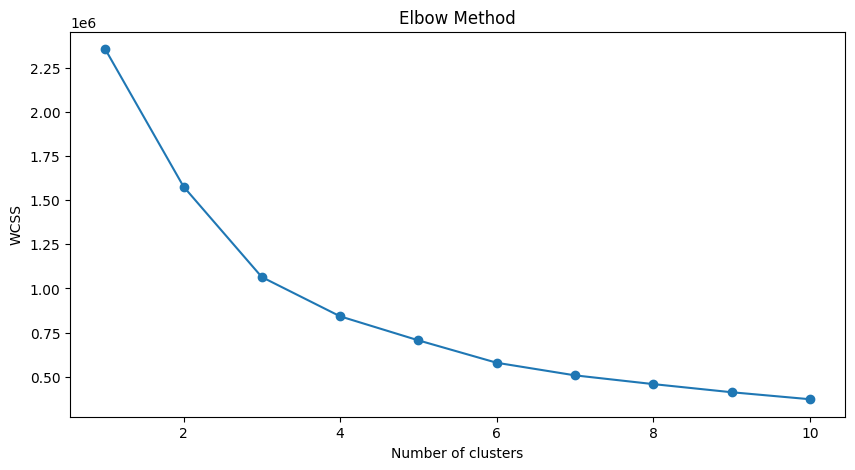

In [157]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), WCSS, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [158]:
kmeans = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10, random_state=0)
df['Cluster'] = kmeans.fit_predict(df)

centroids = kmeans.cluster_centers_

In [159]:
from sklearn.metrics import silhouette_score
silhouette_score = silhouette_score(df[['X_Coordinate', 'Y_Coordinate']], df['Cluster'])
print(f'Silhouette Score: {silhouette_score:.3f}')

Silhouette Score: 0.313


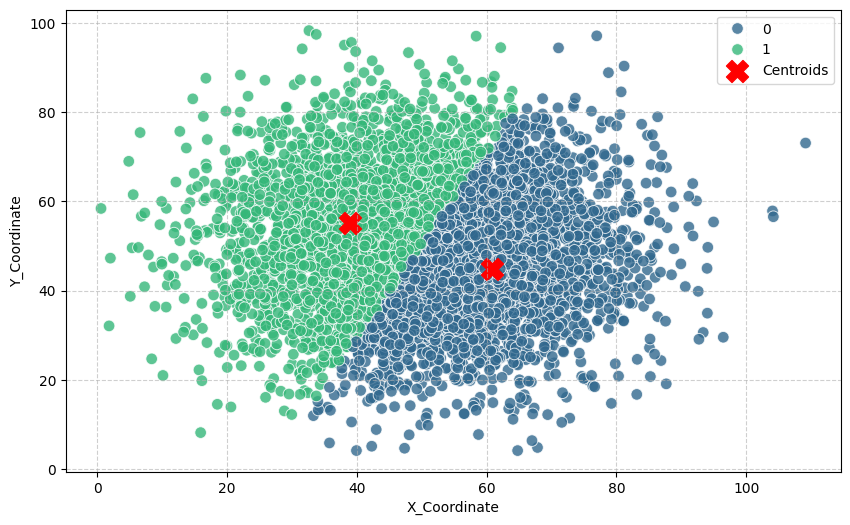

In [160]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='X_Coordinate', 
    y='Y_Coordinate', 
    hue='Cluster', 
    palette='viridis', 
    s=70, 
    alpha=0.8
)
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    s=250, 
    c='red', 
    marker='X', 
    label='Centroids'
)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()